## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score,
                              normalized_mutual_info_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

In [2]:
# Extract the dataset zip files if the data folder is not already present
if not os.path.exists("UCI HAR Dataset"):
    if os.path.exists("human_activity_recognition_using_smartphones.zip"):
        with zipfile.ZipFile("human_activity_recognition_using_smartphones.zip") as z:
            z.extractall(".")
    if os.path.exists("UCI HAR Dataset.zip"):
        with zipfile.ZipFile("UCI HAR Dataset.zip") as z:
            z.extractall(".")

print("Dataset folder found:", os.path.exists("UCI HAR Dataset"))

Dataset folder found: True


In [3]:
DATA_DIR = "UCI HAR Dataset"

# Feature names (561 of them). Some names repeat, so make them unique.
raw_names = [line.split(" ", 1)[1].strip() for line in open(f"{DATA_DIR}/features.txt")]
seen = {}
feature_names = []
for name in raw_names:
    seen[name] = seen.get(name, 0) + 1
    feature_names.append(name if seen[name] == 1 else f"{name}_{seen[name]}")

# Load train and test feature matrices and combine them into one dataset
X_train = pd.read_csv(f"{DATA_DIR}/train/X_train.txt", sep=r"\s+", header=None, names=feature_names)
X_test = pd.read_csv(f"{DATA_DIR}/test/X_test.txt", sep=r"\s+", header=None, names=feature_names)
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

# Load activity labels (1-6) for train and test, and combine
y_train = pd.read_csv(f"{DATA_DIR}/train/y_train.txt", header=None, names=["activity_id"])
y_test = pd.read_csv(f"{DATA_DIR}/test/y_test.txt", header=None, names=["activity_id"])
y_id = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)["activity_id"]

# Map activity id (1-6) to activity name
activity_map = {}
for line in open(f"{DATA_DIR}/activity_labels.txt"):
    idx, act = line.split()
    activity_map[int(idx)] = act
y = y_id.map(activity_map)

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (10299, 561)
y shape: (10299,)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [4]:
print("Activities:", sorted(y.unique()))
y.value_counts()

Activities: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


activity_id
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

## Preprocessing

In [5]:
print("Total missing values in X:", X.isnull().sum().sum())
print("Duplicate rows in X:", X.duplicated().sum())

Total missing values in X: 0


Duplicate rows in X: 0


In [6]:
# Standardize all features (mean 0, std 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled data shape:", X_scaled.shape)
print("Mean of first feature after scaling:", round(X_scaled[:, 0].mean(), 3))
print("Std of first feature after scaling:", round(X_scaled[:, 0].std(), 3))

Scaled data shape: (10299, 561)
Mean of first feature after scaling: -0.0
Std of first feature after scaling: 1.0


## Exploratory Data Analysis

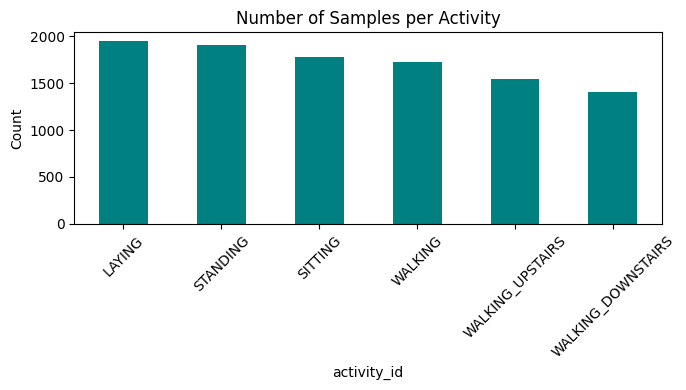

In [7]:
plt.figure(figsize=(7, 4))
y.value_counts().plot(kind="bar", color="teal")
plt.title("Number of Samples per Activity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

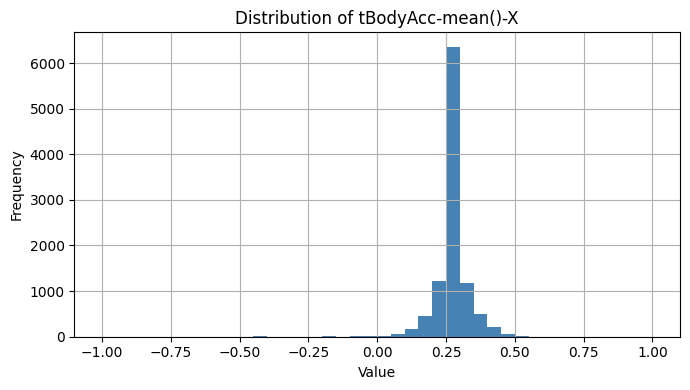

In [8]:
# Distribution of one example feature across activities
plt.figure(figsize=(7, 4))
X["tBodyAcc-mean()-X"].hist(bins=40, color="steelblue")
plt.title("Distribution of tBodyAcc-mean()-X")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Dimensionality Reduction (PCA for 2D Visualization)

In [9]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Explained variance ratio (2 components):", pca_2d.explained_variance_ratio_)
print("Total variance captured by 2 components:", round(pca_2d.explained_variance_ratio_.sum()*100, 2), "%")

Explained variance ratio (2 components): [0.50738221 0.06239186]
Total variance captured by 2 components: 56.98 %


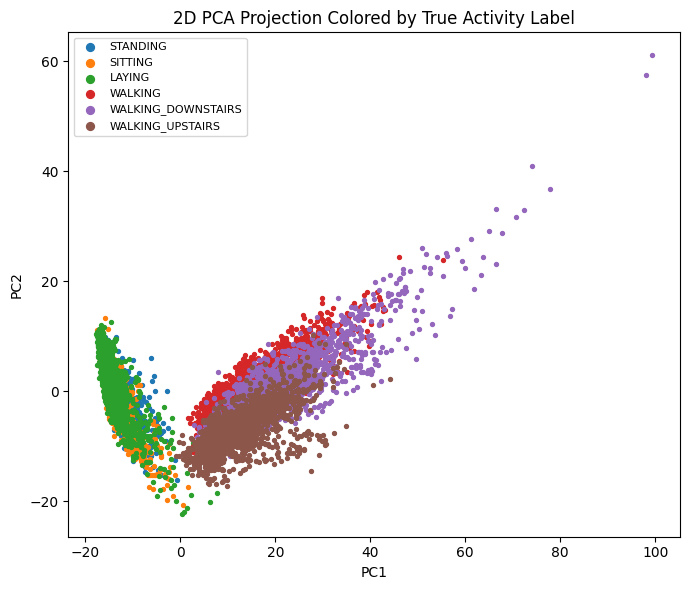

In [10]:
plt.figure(figsize=(7, 6))
for activity in y.unique():
    mask = (y == activity)
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], s=8, label=activity)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection Colored by True Activity Label")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Prepare Data for Clustering

In [11]:
# The full dataset has 10299 samples. To keep clustering (especially hierarchical
# clustering and the dendrogram) fast and readable, we use a random stratified
# subsample of 2000 samples for all three clustering algorithms.
from sklearn.model_selection import train_test_split

X_sub, _, y_sub, _, pca_sub, _ = train_test_split(
    X_scaled, y, X_pca_2d, train_size=2000, stratify=y, random_state=RANDOM_STATE)

print("Subsample shape used for clustering:", X_sub.shape)
y_sub.value_counts()

Subsample shape used for clustering: (2000, 561)


activity_id
LAYING                378
STANDING              370
SITTING               345
WALKING               334
WALKING_UPSTAIRS      300
WALKING_DOWNSTAIRS    273
Name: count, dtype: int64

## K-Means Clustering

In [12]:
k_values = range(2, 9)
wcss_list = []
sil_list = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sub)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_sub, labels))

kmeans_results = pd.DataFrame({"k": list(k_values), "WCSS": wcss_list, "Silhouette": sil_list})
kmeans_results

,k,WCSS,Silhouette
0,2,606723.087023,0.394251
1,3,542496.228895,0.313041
2,4,515761.607995,0.145194
3,5,492134.808858,0.128862
4,6,477471.470910,0.111962
5,7,466218.817527,0.088871
6,8,456462.429103,0.088221


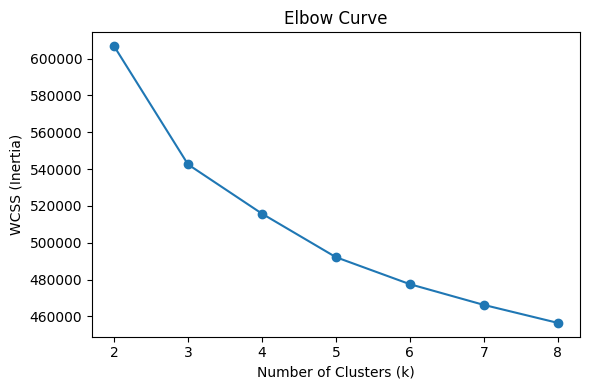

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, wcss_list, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Curve")
plt.tight_layout()
plt.show()

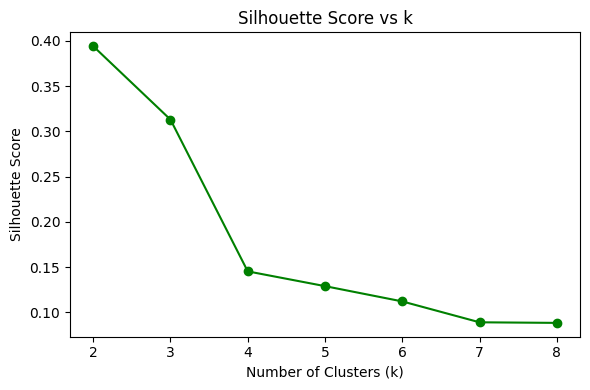

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, sil_list, marker="o", color="green")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

In [15]:
# The silhouette score alone keeps favouring smaller k (it peaks at k=2,
# because the data naturally splits into two big groups: moving activities
# vs stationary activities). But we know from the dataset that there are
# 6 true activities, and the WCSS curve also starts flattening out around
# k=5-6. So we pick k=6 to match the known number of activities, and use
# this for a fair comparison with DBSCAN and Hierarchical clustering later.
best_k = 6
print("Silhouette score would prefer k =", int(kmeans_results.loc[kmeans_results['Silhouette'].idxmax(), 'k']),
      "(2 broad groups: moving vs stationary)")
print("Best k chosen for this experiment:", best_k, "(matches the 6 known activities)")

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_sub)

Silhouette score would prefer k = 2 (2 broad groups: moving vs stationary)
Best k chosen for this experiment: 6 (matches the 6 known activities)


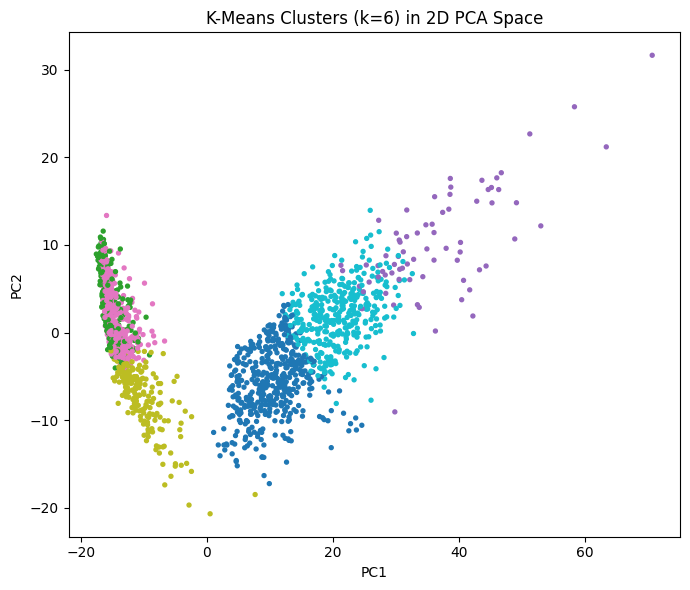

In [16]:
plt.figure(figsize=(7, 6))
plt.scatter(pca_sub[:, 0], pca_sub[:, 1], c=kmeans_labels, cmap="tab10", s=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clusters (k={best_k}) in 2D PCA Space")
plt.tight_layout()
plt.show()

## DBSCAN Clustering

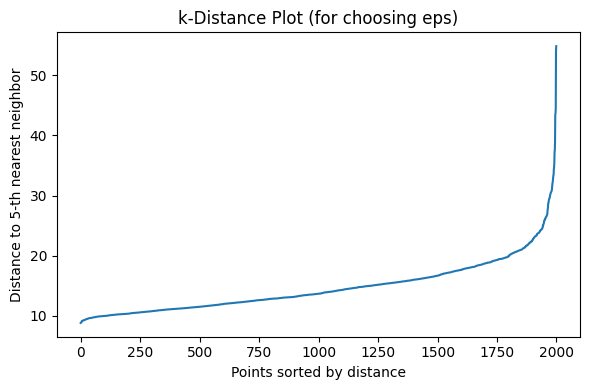

In [17]:
# Use the k-distance plot to help choose a good eps value (k = min_samples)
min_pts = 5
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors.fit(X_sub)
distances, _ = neighbors.kneighbors(X_sub)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_pts}-th nearest neighbor")
plt.title("k-Distance Plot (for choosing eps)")
plt.tight_layout()
plt.show()

In [18]:
# Based on the "elbow" in the k-distance plot above, choose eps
eps_value = 14
dbscan = DBSCAN(eps=eps_value, min_samples=min_pts)
dbscan_labels = dbscan.fit_predict(X_sub)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())
print("eps used:", eps_value, "| min_samples used:", min_pts)
print("Number of clusters found:", n_clusters_db)
print("Number of noise points:", n_noise, f"({n_noise/len(dbscan_labels)*100:.1f}% of the subsample)")

eps used: 14 | min_samples used: 5
Number of clusters found: 6
Number of noise points: 788 (39.4% of the subsample)


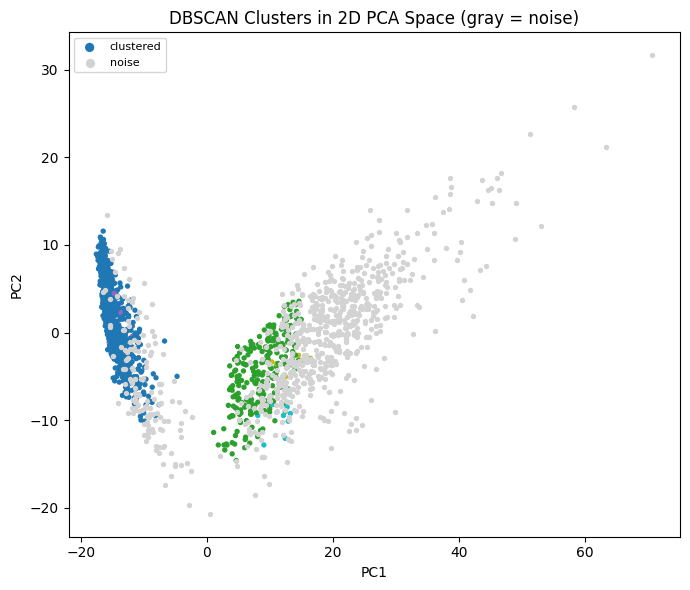

In [19]:
noise_mask = (dbscan_labels == -1)

plt.figure(figsize=(7, 6))
plt.scatter(pca_sub[~noise_mask, 0], pca_sub[~noise_mask, 1],
            c=dbscan_labels[~noise_mask], cmap="tab10", s=8, label="clustered")
plt.scatter(pca_sub[noise_mask, 0], pca_sub[noise_mask, 1],
            c="lightgray", s=8, label="noise")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters in 2D PCA Space (gray = noise)")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Hierarchical Clustering

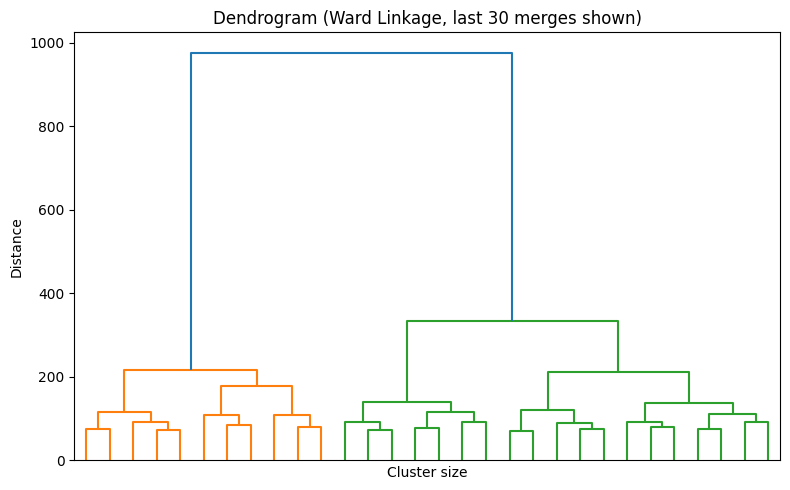

In [20]:
# Ward linkage on the same 2000-sample subset
linked = linkage(X_sub, method="ward")

plt.figure(figsize=(8, 5))
dendrogram(linked, truncate_mode="lastp", p=30, no_labels=True)
plt.title("Dendrogram (Ward Linkage, last 30 merges shown)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [21]:
# Use the same k as K-Means so the algorithms can be compared fairly
hier = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hier_labels = hier.fit_predict(X_sub)
print("Number of clusters used:", best_k)

Number of clusters used: 6


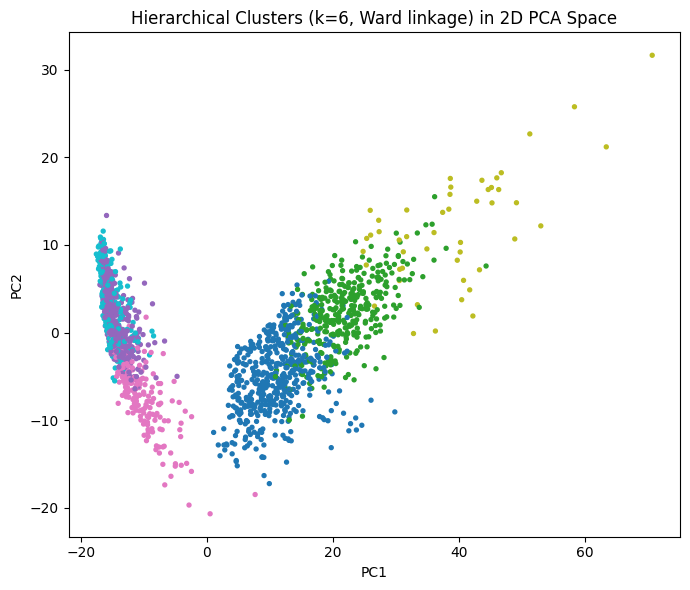

In [22]:
plt.figure(figsize=(7, 6))
plt.scatter(pca_sub[:, 0], pca_sub[:, 1], c=hier_labels, cmap="tab10", s=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hierarchical Clusters (k={best_k}, Ward linkage) in 2D PCA Space")
plt.tight_layout()
plt.show()

## Evaluation Metrics

In [23]:
def evaluate_clustering(X_data, cluster_labels, true_labels):
    # Internal metrics need at least 2 clusters and no single big group of noise.
    # For DBSCAN, noise points (-1) are excluded before computing internal metrics.
    mask = cluster_labels != -1
    n_clusters_found = len(set(cluster_labels[mask]))

    if n_clusters_found >= 2:
        sil = silhouette_score(X_data[mask], cluster_labels[mask])
        dbi = davies_bouldin_score(X_data[mask], cluster_labels[mask])
        chi = calinski_harabasz_score(X_data[mask], cluster_labels[mask])
    else:
        sil, dbi, chi = np.nan, np.nan, np.nan

    ari = adjusted_rand_score(true_labels, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)

    return [sil, dbi, chi, ari, nmi]

rows = []
rows.append(["K-Means"] + evaluate_clustering(X_sub, kmeans_labels, y_sub.values))
rows.append(["DBSCAN"] + evaluate_clustering(X_sub, dbscan_labels, y_sub.values))
rows.append(["Hierarchical"] + evaluate_clustering(X_sub, hier_labels, y_sub.values))

metrics_table = pd.DataFrame(rows, columns=["Algorithm", "Silhouette", "Davies-Bouldin",
                                             "Calinski-Harabasz", "ARI", "NMI"])
metrics_table

,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means,0.111962,2.403915,505.992451,0.433898,0.568284
1,DBSCAN,0.079340,1.796803,161.395126,0.238731,0.382155
2,Hierarchical,0.106532,2.500591,482.452080,0.475722,0.609920


## Comparison of Evaluation Metrics

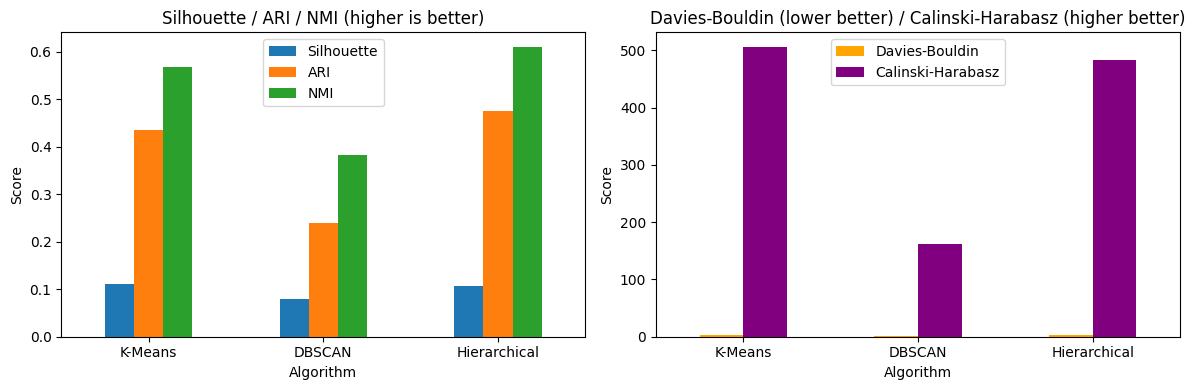

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics_table.plot(x="Algorithm", y=["Silhouette", "ARI", "NMI"], kind="bar", ax=axes[0])
axes[0].set_title("Silhouette / ARI / NMI (higher is better)")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis='x', rotation=0)

metrics_table.plot(x="Algorithm", y=["Davies-Bouldin", "Calinski-Harabasz"], kind="bar", ax=axes[1], color=["orange","purple"])
axes[1].set_title("Davies-Bouldin (lower better) / Calinski-Harabasz (higher better)")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Observation Questions

**1. Which algorithm produced the most meaningful clusters? Why?**

Hierarchical clustering (Ward linkage) matched the true activity labels best, with the highest ARI (0.476) and NMI (0.610) of the three algorithms. K-Means was close behind (ARI 0.434, NMI 0.568). DBSCAN scored clearly lower on both (ARI 0.239, NMI 0.382) even though it had the best (lowest) Davies-Bouldin score (1.80) - because 39.4% of its points were labeled noise instead of being assigned to any activity cluster, which hurts agreement with the ground-truth labels even though the clusters it does form are dense and compact.

**2. How sensitive was K-Means to the choice of k?**

Very sensitive. The silhouette score dropped sharply from 0.394 at k=2 to 0.111 at k=6 and kept falling to 0.088 at k=8. This happens because the data has only two strongly separated geometric groups (moving vs stationary activities); splitting into more clusters (to match the 6 real activities) breaks these into smaller, less geometrically distinct groups, so the "geometrically best" k according to silhouette (k=2) does not match the "semantically correct" k (k=6, the true number of activities).

**3. Did DBSCAN detect noise or small clusters effectively?**

Partially. With eps=14 and min_samples=5, DBSCAN found exactly 6 clusters, matching the number of true activities, but also labeled 788 of 2000 points (39.4%) as noise. It correctly identified dense "core" regions for each activity but struggled at the fuzzy boundaries between similar activities (e.g. SITTING vs STANDING, or the three walking variants), which in this high-dimensional (561-feature) space do not have sharp density gaps. It did not fragment into many useless tiny clusters - most points were either in one of the 6 real clusters or marked as noise.

**4. How does linkage choice affect hierarchical clustering?**

Only Ward linkage was used here, as required. Ward linkage merges clusters in a way that minimizes the increase in total within-cluster variance, which produces compact, similarly-sized clusters and merge distances that increase gradually in the dendrogram (visible above), rather than the "chaining" pattern (one point joining very late) that single linkage is known to produce. Because Ward's variance-minimizing objective is similar in spirit to K-Means, it is expected to behave similarly to K-Means - and indeed Hierarchical and K-Means gave the closest results of the three algorithms here (Silhouette 0.107 vs 0.112, similar Calinski-Harabasz scores). Complete or single linkage were not tested, but are generally known to be more sensitive to outliers (single) or to produce more balanced but not variance-optimal clusters (complete).

**5. Which internal metric best matched the visual intuition of cluster quality?**

The Calinski-Harabasz Index matched the visual PCA scatter plots best: it clearly separated the two visually "good" algorithms (K-Means 506.0, Hierarchical 482.5) from the visually noisier DBSCAN result (161.4, with many gray noise points scattered through the plot). The Davies-Bouldin Index was misleading here - it actually favored DBSCAN (1.80, lower is better) even though DBSCAN's plot looks visually worse overall, because Davies-Bouldin only evaluates the points that were confidently assigned to a cluster and ignores the large fraction left as noise.